# Week 5 — segment calibration (Wednesday, 1 hour)

Six exercises on fc-10's `segments` module and Decision 3. Everything is computed by fc-10's own code on the
same seeded population; nothing is copied here. Every rate is **PLANTED TRUTH**.

Run with `FC10_REPOSITORY` set (see `training/README.md`). Read `README.md` in this folder first.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.insert(0, str(Path.cwd().parents[1]))
from tools.tm_sim_source import load, fc10_module

tm_sim, metrics = load()
segments = fc10_module("runtime.manufacturing.tuning.segments")
decision_log = fc10_module("runtime.manufacturing.tuning.decision_log")
sns.set_theme(style="whitegrid")

pop = tm_sim.generate()
hold = tm_sim.generate(seed=20260925)
BUDGET = 2419                                    # D2's workload: customer-months a year at GBP 75k
TWO = {"retail": ["retail"], "non_retail": ["business", "corporate", "correspondent"]}
print(f"fit population {pop.digest()[:12]}… · hold-out {hold.digest()[:12]}… · budget {BUDGET:,}")

fit population 7dc1ddbc19ba… · hold-out 09b8cfa06441… · budget 2,419


## Exercise 1 — who the customers are

The four KYC types, how many were planted in each, and each customer's largest payment. Note how few planted
customers corporate and correspondent have: that decides how far any line fitted to them can be trusted.

,customers,planted
segment,,
retail,3621,156
business,901,34
corporate,320,9
correspondent,158,1


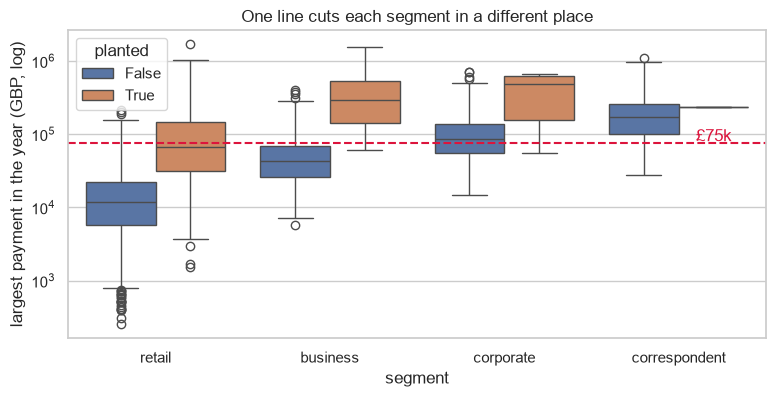

In [2]:
cust = pd.DataFrame([{"segment": c.segment, "planted": c.planted, "scale": c.scale} for c in pop.customers])
cust["max_amount"] = [pop.max_amount_by_customer()[c.customer_id] for c in pop.customers]
order = list(tm_sim.SEGMENTS)
display(cust.groupby("segment").agg(customers=("planted", "size"), planted=("planted", "sum")).loc[order])

fig, ax = plt.subplots(figsize=(9, 4))
sns.boxplot(cust, x="segment", y="max_amount", hue="planted", order=order, log_scale=True, ax=ax)
ax.axhline(75_000, ls="--", c="crimson"); ax.text(3.1, 80_000, "£75k", color="crimson")
ax.set(ylabel="largest payment in the year (GBP, log)", title="One line cuts each segment in a different place")
plt.show()

## Exercise 2 — the curriculum's example, and its trap

The curriculum suggested *Retail £20k, Corporate £100k*. Score that against today's single £75k line.
Then look at the workload column before believing the catch column.

In [3]:
rows = {}
rows["single £75k"] = segments.evaluate(pop, "high_value", {s: 75_000 for s in order})
rows["retail £20k / others £100k"] = segments.evaluate(pop, "high_value",
    {"retail": 20_000, "business": 100_000, "corporate": 100_000, "correspondent": 100_000})
pd.DataFrame({k: {m: v[m] for m in ("tp", "workload", "customers_alerted", "recall")} for k, v in rows.items()}).T

,tp,workload,customers_alerted,recall
single £75k,110.0,2419.0,679.0,0.55
retail £20k / others £100k,166.0,5260.0,1529.0,0.83


The split catches more, but it also makes a different amount of work, so the comparison isn't fair yet. A segmented
rule has to beat one line **at the same workload**. Exercise 3 does that.

## Exercise 3 — the same budget: one line, two lines, one per segment

`segments.compare` fits the lines on the population **within the budget**, then scores them there and on the
hold-out.

In [4]:
one_per_seg = segments.compare(pop, hold, "high_value", BUDGET)
two_lines = segments.compare(pop, hold, "high_value", BUDGET, groups=TWO)
table = pd.DataFrame({
    "one line":        {"lines": 1, "fitted": two_lines["in_sample"]["single"]["tp"], "hold-out": two_lines["hold_out"]["single"]["tp"]},
    "two lines":       {"lines": 2, "fitted": two_lines["in_sample"]["segmented"]["tp"], "hold-out": two_lines["hold_out"]["segmented"]["tp"]},
    "one per segment": {"lines": 4, "fitted": one_per_seg["in_sample"]["segmented"]["tp"], "hold-out": one_per_seg["hold_out"]["segmented"]["tp"]},
}).T
print("two lines:", two_lines["in_sample"]["segmented"]["group_thresholds"])
print("four lines:", one_per_seg["in_sample"]["segmented"]["group_thresholds"], "· thin:", one_per_seg["complexity"]["thin_segments"])
table

two lines: {'retail': 30000, 'non_retail': 152500}
four lines: {'retail': 30000, 'business': 95000, 'corporate': 155000, 'correspondent': 200000} · thin: ['corporate', 'correspondent']


,lines,fitted,hold-out
one line,1,110,122
two lines,2,151,149
one per segment,4,155,154


## Exercise 4 — what survives the hold-out

The gap between the **fitted** and **hold-out** catch is how much of a gain was fit to this population's accidents.
Repeat Exercise 3 at three budgets.

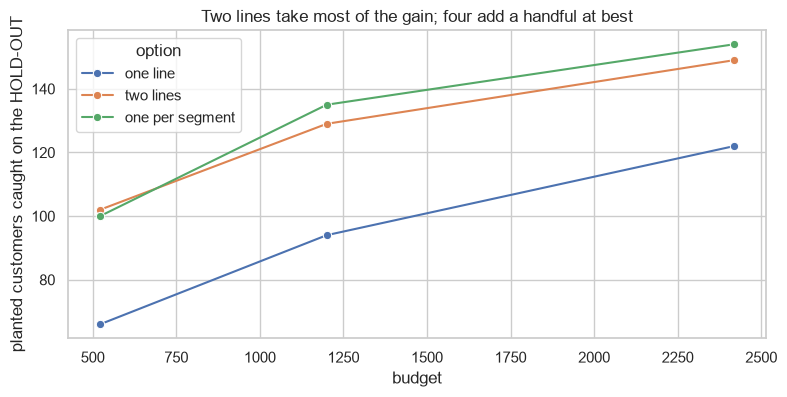

fitted                           hold-out                          
option one line one per segment two lines one line one per segment two lines
budget                                                                      
522          65              98        98       66             100       102
1200         85             135       133       94             135       129
2419        110             155       151      122             154       149

In [5]:
rows = []
for b in (522, 1200, BUDGET):
    four, two = segments.compare(pop, hold, "high_value", b), segments.compare(pop, hold, "high_value", b, groups=TWO)
    for name, r, arm in (("one line", two, "single"), ("two lines", two, "segmented"), ("one per segment", four, "segmented")):
        rows.append({"budget": b, "option": name, "fitted": r["in_sample"][arm]["tp"], "hold-out": r["hold_out"][arm]["tp"]})
gap = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(9, 4))
sns.lineplot(gap, x="budget", y="hold-out", hue="option", marker="o", ax=ax)
ax.set(ylabel="planted customers caught on the HOLD-OUT", title="Two lines take most of the gain; four add a handful at best")
plt.show()
gap.pivot(index="budget", columns="option", values=["fitted", "hold-out"])

## Exercise 5 — a thin line moves

Refit the four per-segment lines on five fresh populations (seeds 20260925–29), and watch what a line's
planted count does to it.

In [6]:
fits = []
for seed in range(20260925, 20260930):
    p = tm_sim.generate(seed=seed)
    f = segments.fit(segments.curves(p, "high_value"), BUDGET)
    fits.append({"seed": seed, **f["thresholds"]})
lines = pd.DataFrame(fits).set_index("seed")
display(lines)
lines.agg(["min", "max"]).T.assign(spread=lambda d: d["max"] - d["min"])

,retail,business,corporate,correspondent
seed,,,,
20260925,35000,82500,135000,200000
20260926,30000,130000,167500,200000
20260927,30000,85000,167500,200000
20260928,30000,110000,200000,200000
20260929,30000,97500,192500,200000


,min,max,spread
retail,30000,35000,5000
business,82500,130000,47500
corporate,135000,200000,65000
correspondent,200000,200000,0


Retail (156 planted) barely moves. Business (34) and corporate (9) swing by tens of thousands of pounds from one
population to the next, so even a line above the 10-planted floor is not stable. Correspondent (1 planted) doesn't
move at all, and that's the warning sign: it sits at the top of the grid every time because the fit has effectively
**switched that line off**. It's a line in name only, catching no one, that someone would still have to document and
defend. Grouping business, corporate and correspondent into one "non-retail" line is what Decision 3 did about it.

## Exercise 6 — Decision 3, as logged

The Tuning Decision Log recomputes this evidence on every test run, so what you read here is what the code
produces now.

In [7]:
[d3] = [e for e in decision_log.load() if e["decision_id"] == "D3"]
print(d3["decision"], d3["to_thresholds"], "· applied:", d3["applied"])
print()
print(d3["rationale"])
print()
print("revisit:", d3["revisit"])

SEGMENT {'non_retail': 152500, 'retail': 30000} · applied: False

Two lines: retail GBP 30,000, everyone else (business, corporate, correspondent) GBP 152,500. At D2's workload (2,419 customer-months a year) the two lines catch 149 of 200 planted customers on a hold-out population, against 122 for the best single line (151 vs 110 where they were fitted). One line per segment catches 154 on the hold-out, but corporate (9 planted) and correspondent (1) sit below the 10-planted floor, so four lines buy a handful more catches with two lines nobody could defend. At a 522 budget two lines (102) match or beat four (100). Decided, not applied: the registry stays at GBP 75,000 until the governed apply step, and it cannot yet express a per-segment threshold at all.

revisit: Apply in week 9 through the governed step, which must first teach the TM rule registry per-segment thresholds. Re-run against week 6's customer-baseline challenger, which may beat any amount line. Segment membership is model

## Your answers (the curriculum's success criteria)

1. **Explain the improvement Decision 3 achieves, in numbers that survive the hold-out.**

    *…*

2. **Why not four lines?** Use Exercises 3 and 5.

    *…*

3. **What unjustified complexity would look like here, and how you'd spot it.**

    *…*